In [312]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from networkx.algorithms.community import modularity

In [313]:
G = nx.Graph()
n = 6
remove = 5
seed=59
#seed = np.random.randint(1, 100)

clique1 = list(range(n))
G.add_edges_from(nx.complete_graph(n).edges(data=False))

clique2 = list(range(n, 2*n))
K2 = nx.complete_graph(n)
K2 = nx.complete_graph(n)
mapping = {i: i + n for i in range(n)}
H = nx.relabel_nodes(K2, mapping)
G.add_edges_from(H.edges(data=False))
random.seed(seed)
edges = random.sample(list(G.edges()), remove)
G.remove_edges_from(edges)
G.add_edge(n-1, n+1) # Conecta el último nodo del C1 con el primero del C2
#G.add_edge(1, n+3) # Conecta el último nodo del C1 con el primero del C2



In [314]:
seed


59

In [315]:
pos = nx.spring_layout(G, k=1, iterations=200, seed=seed)

In [316]:
def draw_partition(G, pos, partition, title=None):
    """
    partition: lista de conjuntos de nodos, p.ej. [ {0,1,2,3,4}, {5,6,7,8,9} ]
    """
    # Asignar un color por comunidad
    communities = list(partition)
    color_map = {}
    palette = [
        "red", "blue", "green", "orange", "purple",
        "brown", "pink", "gray", "olive", "cyan"
    ]

    for i, comm in enumerate(communities):
        for node in comm:
            color_map[node] = palette[i % len(palette)]

    node_colors = [color_map[node] for node in G.nodes()]

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600)
    nx.draw_networkx_edges(G, pos, edge_color="darkgray", width=2, alpha=0.6)
    #nx.draw_networkx_labels(G, pos, font_color="white")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

Modularidad (cliques): 0.46079881656804733


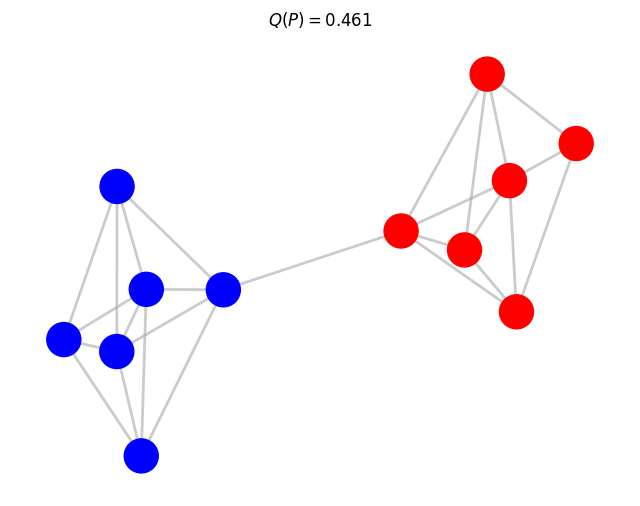

In [317]:
# =========================================
# 3. Partición “natural” (cada clique es una comunidad)
# =========================================
partition_cliques = [set(clique1), set(clique2)]
Q_cliques = modularity(G, partition_cliques)
print("Modularidad (cliques):", Q_cliques)

draw_partition(G, pos, partition_cliques,
               title=f"$Q(P) = {Q_cliques:.3f}$")

Modularidad (aleatoria): -0.000739644970414205


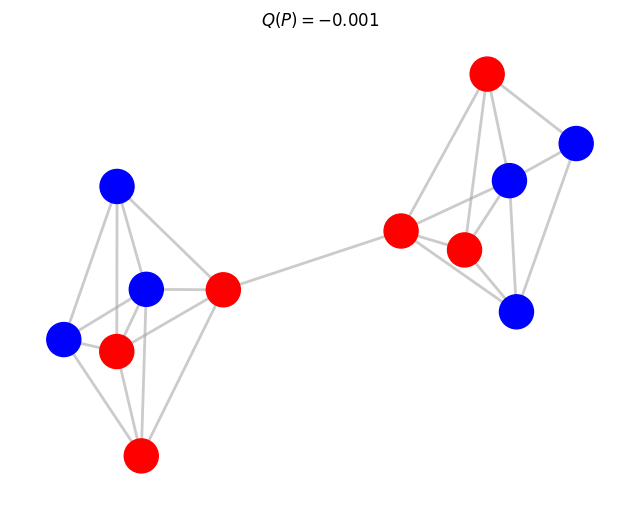

In [318]:
# =========================================
# 4. Partición aleatoria y su modularidad
#    (2 comunidades con tamaño similar)
# =========================================
nodes = list(G.nodes())
random.shuffle(nodes)
cut = len(nodes) // 2
part_random = [set(nodes[:cut]), set(nodes[cut:])]

Q_random = modularity(G, part_random)
print("Modularidad (aleatoria):", Q_random)

draw_partition(G, pos, part_random,
               title=f"$Q(P) = {Q_random:.3f}$")